In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:
grids = np.array([32, 64, 96, 128, 160, 192, 256, 320])

#Total, PDE, QSP, ABM
PDAC = np.array([[204.69, 296.03, 447.20, 801.36, 1204.54, 1743.69, 4032.84, 92494.12],
                 [21.55, 33.24, 45.02, 79.84, 152.70, 285.37, 1341.17, 2999.49],
                 [15.81, 15.79, 15.97, 15.40, 15.82, 16.58, 15.96, 15.18],
                 [167.33, 247.01, 386.21, 706.12, 1036.02, 1441.74, 2675.71, 89479.47]]) / 1000

HCC  = np.array([[np.nan, 7167, 25875, 66349, 128706, 238536, np.nan, np.nan],
                 [np.nan, 5312, 18755, 47428, 89038, 165309, np.nan, np.nan],
                 [np.nan, 38, 38, 38, 37, 38, np.nan, np.nan],
                 [np.nan, 7129, 25837, 66310, 128668, 238536, np.nan, np.nan]]) / 1000


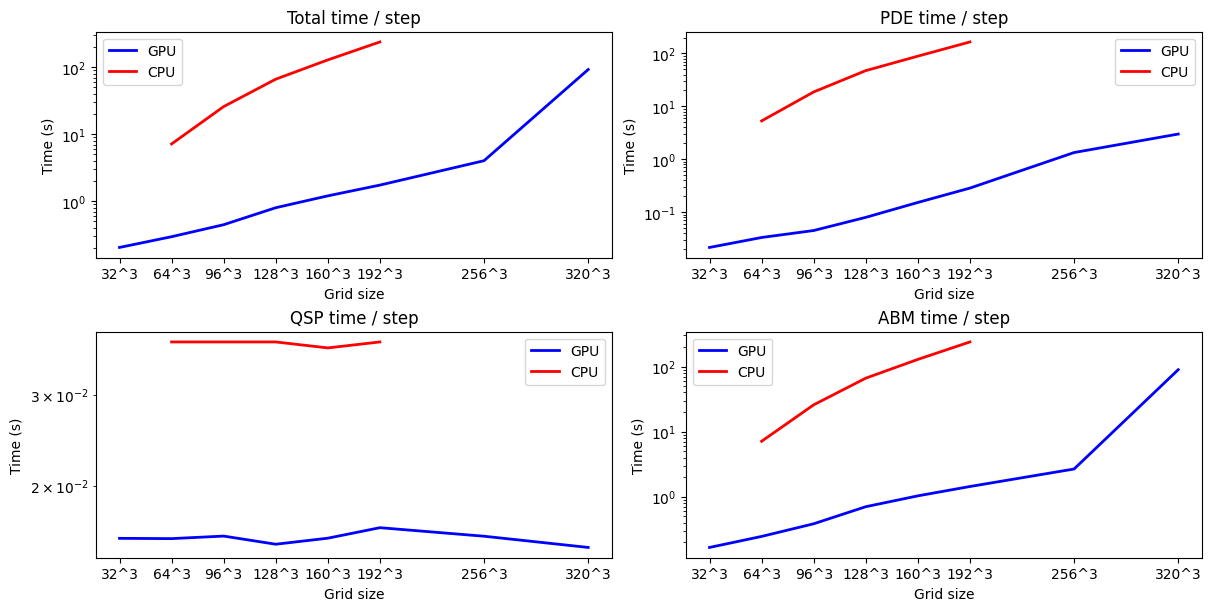

In [19]:
ticks = []
for elem in grids:
    ticks.append(str(elem)+'^3')
    
fig, axes = plt.subplots(2,2,figsize=(12,6),layout='constrained')
titles = ['Total time / step', 'PDE time / step', 'QSP time / step', 'ABM time / step']
for i, ax in enumerate(axes.reshape(-1)):
    ax.plot(grids, PDAC[i,:], label = 'GPU', color='blue', linewidth = 2)

    ax.plot(grids, HCC[i,:], label = 'CPU', color='red', linewidth = 2)
    ax.set_xticks(grids, labels = ticks)
    ax.set_xlabel('Grid size')
    ax.set_ylabel('Time (s)')
    ax.set_title(titles[i])
    ax.set_yscale('log')
    ax.legend()

plt.savefig('CPUvGPU_timeperstep.png')

[         nan  24.21038408  57.86001789  82.79549765 106.850748
 136.79954579          nan          nan]


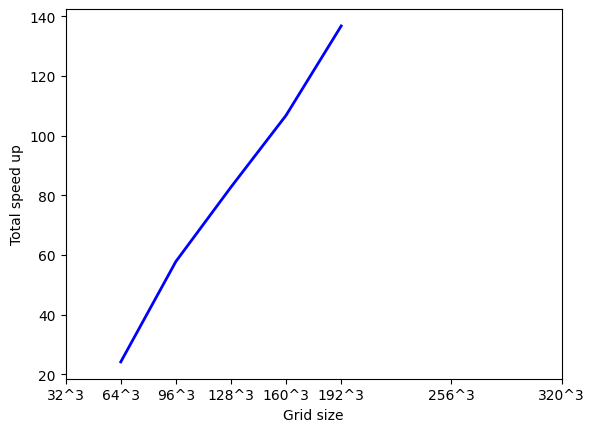

In [20]:
# SPEED UP
SU = HCC[0,:] / PDAC[0,:]
print(SU)

plt.plot(grids, SU, color='blue', linewidth=2)
plt.xlabel('Grid size')
plt.xticks(grids, labels = ticks)
plt.ylabel('Total speed up')
plt.savefig('CPUvGPU_speedup.png')